In [ ]:
Aluna: Nathália Rayanne Lima Araújo

# Regressão Softmax com dados do MNIST

## Objetivo

O objetivo deste notebook é ilustrar o uso de praticamente a mesma rede desenvolvida para a classificação das flores Íris, porém agora com o problema de classificação de dígitos manuscritos utilizando o dataset MNIST.
As principais diferenças são:
- tipo do dado, agora imagem com muito atributos: 28 x 28 pixels
- número de amostras, muito maior, 60 mil
Neste exercício será possível a interpretação do significado dos parâmetros treinados

## Importação das bibliotecas

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
from torch.autograd import Variable

import torchvision

## Carregamento dos dados do MNIST

In [ ]:
! git clone https://github.com/vcasadei/MNIST.git

Cloning into 'MNIST'...
remote: Enumerating objects: 10, done.
remote: Total 10 (delta 0), reused 0 (delta 0), pack-reused 10 (from 1)
Receiving objects: 100% (10/10), 11.01 MiB | 2.72 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [ ]:
!ls MNIST

processed  raw


In [ ]:
dataset_dir = 'MNIST/'

x_train, y_train = torch.load(dataset_dir + 'processed/training.pt')

print("Amostras de treinamento:", x_train.size(0))

print("\nDimensões dos dados das imagens:   ", x_train.size())
print("Valores mínimo e máximo dos pixels:", torch.min(x_train), torch.max(x_train))
print("Tipo dos dados das imagens:        ", type(x_train))
print("Tipo das classes das imagens:      ", type(y_train))

Amostras de treinamento: 60000

Dimensões dos dados das imagens:    torch.Size([60000, 28, 28])
Valores mínimo e máximo dos pixels: tensor(0, dtype=torch.uint8) tensor(255, dtype=torch.uint8)
Tipo dos dados das imagens:         <class 'torch.Tensor'>
Tipo das classes das imagens:       <class 'torch.Tensor'>


### Carregamento, normalização e seleção dos dados do MNIST

Neste exemplo utilizaremos apenas 1000 amostras de treinamento.

In [ ]:
x_train = x_train.float()

x_train = x_train / 255.

if True:
    n_samples_train = 1000

    x_train = x_train[:n_samples_train]
    y_train = y_train[:n_samples_train]

print("Amostras de treinamento:", x_train.size(0))

print("\nDimensões dos dados das imagens:   ", x_train.size())
print("Valores mínimo e máximo dos pixels:", torch.min(x_train), torch.max(x_train))
print("Tipo dos dados das imagens:        ", type(x_train))
print("Tipo das classes das imagens:      ", type(y_train))

Amostras de treinamento: 1000

Dimensões dos dados das imagens:    torch.Size([1000, 28, 28])
Valores mínimo e máximo dos pixels: tensor(0.) tensor(1.)
Tipo dos dados das imagens:         <class 'torch.Tensor'>
Tipo das classes das imagens:       <class 'torch.Tensor'>


### Carregamento e normalização dos dados de validação

In [ ]:
x_val, y_val = torch.load(dataset_dir + 'processed/test.pt')

x_val = x_val.float()
x_val = x_val / 255.

# Limit validation samples for consistency with training set, if needed
# If you want to use the full test set for validation, comment this block
if True:
    n_samples_val = 200 # Using a smaller validation set for demonstration

    x_val = x_val[:n_samples_val]
    y_val = y_val[:n_samples_val]

print("Amostras de validação:", x_val.size(0))

print("\nDimensões dos dados das imagens de validação:   ", x_val.size())
print("Valores mínimo e máximo dos pixels de validação:", torch.min(x_val), torch.max(x_val))
print("Tipo dos dados das imagens de validação:        ", type(x_val))
print("Tipo das classes das imagens de validação:      ", type(y_val))

Amostras de validação: 200

Dimensões dos dados das imagens de validação:    torch.Size([200, 28, 28])
Valores mínimo e máximo dos pixels de validação: tensor(0.) tensor(1.)
Tipo dos dados das imagens de validação:         <class 'torch.Tensor'>
Tipo das classes das imagens de validação:       <class 'torch.Tensor'>


### Visualizando os dados

(np.float64(-0.5), np.float64(232.5), np.float64(87.5), np.float64(-0.5))

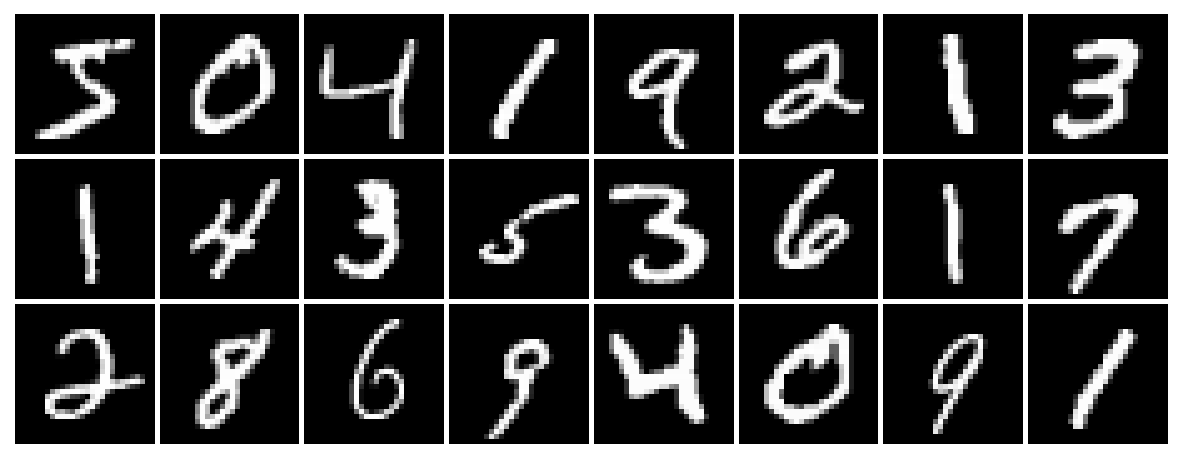

In [ ]:
n_samples = 24

# cria um grid com as imagens
grid = torchvision.utils.make_grid(x_train[:n_samples].unsqueeze(dim=1), pad_value=1.0, padding=1)

plt.figure(figsize=(15, 10))
plt.imshow(grid.numpy().transpose(1, 2, 0))
plt.axis('off')

### Visualizando uma imagem com o matplotlib

class: tensor(5)


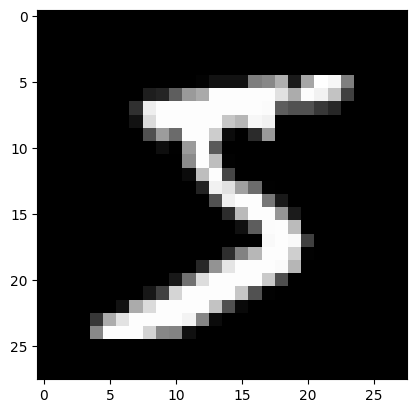

In [ ]:
image  = x_train[0]
target = y_train[0]

plt.imshow(image.numpy(), cmap='gray')
print('class:', target)

## Modelo

In [ ]:
model = torch.nn.Linear(28*28, 10) # 28*28 atributos de entrada e 10 neurônios na sáida

### Testando um predict com poucas amostras

In [ ]:
xin = x_train[:5].view(-1,28*28)
score = model(Variable(xin))
score

tensor([[-0.2619,  0.2169,  0.2421,  0.1011,  0.0589,  0.1877,  0.0988,  0.3585,
         -0.1144,  0.0614],
        [-0.1155, -0.0699,  0.1761,  0.0273, -0.0869,  0.3639,  0.0500,  0.1825,
         -0.3700, -0.2617],
        [-0.0318, -0.0376,  0.0683,  0.1373, -0.0936,  0.0639, -0.0815, -0.0307,
         -0.0544,  0.2003],
        [-0.0692, -0.0448,  0.0309,  0.1492,  0.2603,  0.0876,  0.1219,  0.4154,
         -0.2241, -0.0733],
        [-0.1060,  0.0699,  0.1972,  0.1393,  0.2545,  0.1082,  0.2136,  0.0815,
          0.1539, -0.1679]], grad_fn=<AddmmBackward0>)

## Treinamento

### Inicialização dos parâmetros

In [ ]:
epochs = 100
learningRate = 0.5

# Utilizaremos CrossEntropyLoss como função de perda
criterion = torch.nn.CrossEntropyLoss()

# Gradiente descendente
optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)

### Laço de treinamento dos pesos

In [ ]:
import numpy
losses = []
zs = []

for i in range(epochs):
    # Transforma a entrada para uma dimensão
    inputs = Variable(x_train.view(-1, 28 * 28))
    # Predict da rede
    outputs = model(inputs)

    # z0 a z9
    zs.append(outputs[1].detach().numpy())

    # calcula a perda
    loss = criterion(outputs, Variable(y_train))

    # zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    _, predicts = torch.max(outputs, 1)

    y_pred = predicts.data
    accuracy = (y_pred.numpy() == y_train.numpy()).mean()


### Laço de treinamento dos pesos (com validação e armazenamento de métricas)

In [ ]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for i in range(epochs):
    # Passada de treinamento
    inputs_train = Variable(x_train.view(-1, 28 * 28))
    outputs_train = model(inputs_train)
    loss_train = criterion(outputs_train, Variable(y_train))

    # Zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss_train.backward()
    optimizer.step()

    train_losses.append(loss_train.item())

    _, predicts_train = torch.max(outputs_train, 1)
    accuracy_train = (predicts_train.data.numpy() == y_train.numpy()).mean()
    train_accuracies.append(accuracy_train)

    # Passada de validação
    with torch.no_grad(): # Desabilita o cálculo de gradientes para validação
        inputs_val = Variable(x_val.view(-1, 28 * 28))
        outputs_val = model(inputs_val)
        loss_val = criterion(outputs_val, Variable(y_val))
        val_losses.append(loss_val.item())

        _, predicts_val = torch.max(outputs_val, 1)
        accuracy_val = (predicts_val.data.numpy() == y_val.numpy()).mean()
        val_accuracies.append(accuracy_val)

    print(f'Epoch [{i+1}/{epochs}], ' \
          f'Train Loss: {loss_train.item():.4f}, ' \
          f'Train Acc: {accuracy_train:.4f}, ' \
          f'Val Loss: {loss_val.item():.4f}, ' \
          f'Val Acc: {accuracy_val:.4f}')

Epoch [1/100], Train Loss: 0.2640, Train Acc: 0.9430, Val Loss: 0.3987, Val Acc: 0.8900
Epoch [2/100], Train Loss: 0.2627, Train Acc: 0.9430, Val Loss: 0.3978, Val Acc: 0.8950
Epoch [3/100], Train Loss: 0.2614, Train Acc: 0.9430, Val Loss: 0.3968, Val Acc: 0.9000
Epoch [4/100], Train Loss: 0.2601, Train Acc: 0.9430, Val Loss: 0.3959, Val Acc: 0.9000
Epoch [5/100], Train Loss: 0.2588, Train Acc: 0.9440, Val Loss: 0.3950, Val Acc: 0.9050
Epoch [6/100], Train Loss: 0.2576, Train Acc: 0.9440, Val Loss: 0.3941, Val Acc: 0.9050
Epoch [7/100], Train Loss: 0.2563, Train Acc: 0.9440, Val Loss: 0.3933, Val Acc: 0.9050
Epoch [8/100], Train Loss: 0.2551, Train Acc: 0.9440, Val Loss: 0.3924, Val Acc: 0.9050
Epoch [9/100], Train Loss: 0.2539, Train Acc: 0.9450, Val Loss: 0.3916, Val Acc: 0.9050
Epoch [10/100], Train Loss: 0.2527, Train Acc: 0.9460, Val Loss: 0.3907, Val Acc: 0.9050
Epoch [11/100], Train Loss: 0.2515, Train Acc: 0.9460, Val Loss: 0.3899, Val Acc: 0.9050
Epoch [12/100], Train Loss: 0.

In [ ]:
print('Final loss:', loss.item())

Final loss: 0.2653433084487915


### Visualizando gráfico de perda durante o treinamento

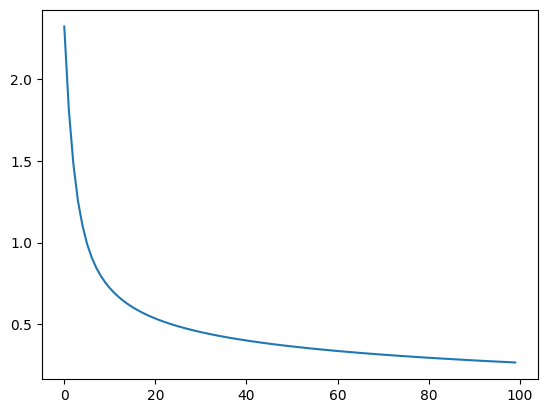

In [ ]:
plt.plot(losses)

### Visualizando gráficos de perda e acurácia durante o treinamento

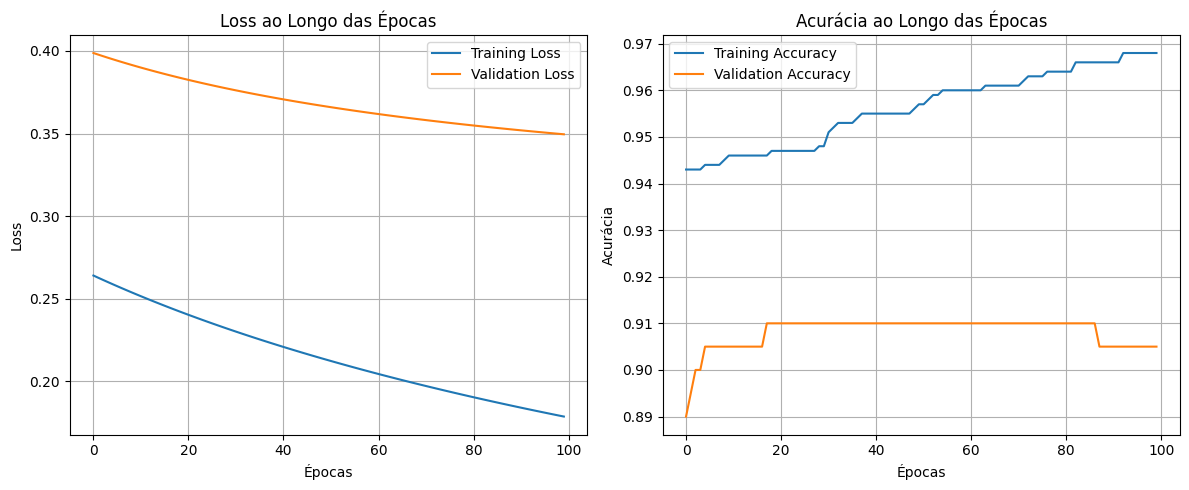

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss ao Longo das Épocas')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Acurácia ao Longo das Épocas')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Avaliação

### Acurácia tanto no conjunto de treinamento como no conjunto de testes

In [ ]:
def predict(model, input_data):
    outputs = model(Variable(input_data))
    _, predicts = torch.max(outputs, 1)

    return predicts.data

y_pred = predict(model, x_train.view(-1, 28*28))
accuracy = (y_pred.numpy() == y_train.numpy()).mean()
print('Accuracy:', accuracy)

Accuracy: 0.968


### Matriz de confusão com dados de treinamento e teste

In [ ]:
print('Matriz de confusão:')
pd.crosstab(y_pred.numpy(), y_train.numpy())

Matriz de confusão:


col_0,0,1,2,3,4,5,6,7,8,9
row_0,,,,,,,,,,
0,97,0,1,0,0,0,0,0,0,2
1,0,112,1,0,0,0,0,2,1,0
2,0,0,93,2,0,1,0,1,0,0
3,0,0,0,90,0,1,0,0,0,0
4,0,0,0,0,104,1,0,1,0,2
5,0,2,0,1,0,87,0,0,1,1
6,0,0,1,0,0,1,94,0,0,0
7,0,0,1,0,0,0,0,113,0,2
8,0,1,1,0,0,0,0,0,85,0


## Visualizando a matriz de pesos treinados

Observe que a matriz de peso treinado para cada classe mostra a importância dos pesos associados aos caracteres de cada classe.

weights: torch.Size([10, 784])
bias:    torch.Size([10])


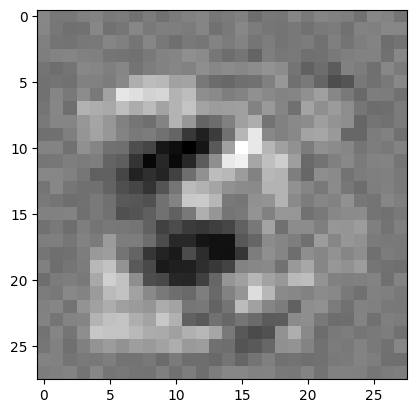

In [ ]:
weights = model.state_dict()['weight']
print('weights:', weights.shape)

bias = model.state_dict()['bias']
print('bias:   ', bias.shape)

# Visualizando pesos da classe 3
plt.imshow(weights[3, :].numpy().reshape((28,28)),cmap = 'gray')
plt.show()

### Visualizando os pesos de todas as classes

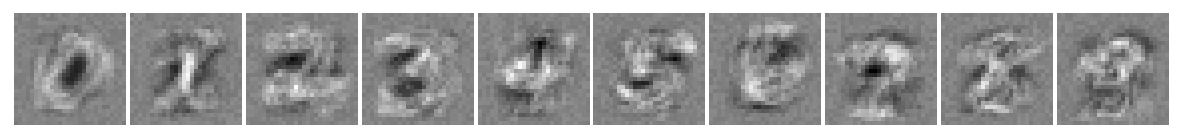

In [ ]:
# cria um grid com as imagens
grid = torchvision.utils.make_grid(weights.view(-1, 1, 28, 28), normalize=True, pad_value=1.0, padding=1, nrow=10)

plt.figure(figsize=(15, 10))
plt.imshow(grid.numpy().transpose(1, 2, 0))
plt.axis('off');

### Diagrama da regressão softmax com visualização dos pesos W

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/RegressaoSoftmaxArgmaxNMIST.png)

# Atividades

## Exercícios

- 1) Insira código no laço do treinamento para que no final de cada época,
     seja impresso: o número da época e a perda e a acurácia

In [ ]:
losses = []
zs = []

for i in range(epochs):
    # Transforma a entrada para uma dimensão
    inputs = Variable(x_train.view(-1, 28 * 28))
    # Predict da rede
    outputs = model(inputs)

    # z0 a z9
    zs.append(outputs[1].detach().numpy())

    # calcula a perda
    loss = criterion(outputs, Variable(y_train))

    # zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    _, predicts = torch.max(outputs, 1)

    y_pred = predicts.data
    accuracy = (y_pred.numpy() == y_train.numpy()).mean()

    print('Epoch[{}/{}], perda: {:.6f}, acurácia: {:.6f}'
              .format(i+1, epochs, loss.data, accuracy))


Epoch[1/100], perda: 0.178049, acurácia: 0.968000
Epoch[2/100], perda: 0.177476, acurácia: 0.968000
Epoch[3/100], perda: 0.176906, acurácia: 0.968000
Epoch[4/100], perda: 0.176340, acurácia: 0.968000
Epoch[5/100], perda: 0.175778, acurácia: 0.968000
Epoch[6/100], perda: 0.175219, acurácia: 0.968000
Epoch[7/100], perda: 0.174663, acurácia: 0.968000
Epoch[8/100], perda: 0.174111, acurácia: 0.968000
Epoch[9/100], perda: 0.173562, acurácia: 0.968000
Epoch[10/100], perda: 0.173016, acurácia: 0.968000
Epoch[11/100], perda: 0.172474, acurácia: 0.968000
Epoch[12/100], perda: 0.171934, acurácia: 0.968000
Epoch[13/100], perda: 0.171399, acurácia: 0.969000
Epoch[14/100], perda: 0.170866, acurácia: 0.969000
Epoch[15/100], perda: 0.170336, acurácia: 0.969000
Epoch[16/100], perda: 0.169810, acurácia: 0.969000
Epoch[17/100], perda: 0.169286, acurácia: 0.969000
Epoch[18/100], perda: 0.168766, acurácia: 0.969000
Epoch[19/100], perda: 0.168248, acurácia: 0.969000
Epoch[20/100], perda: 0.167734, acurácia

- 2) Insira código no laço do treinamento para visualização dos valores dos gradientes referentes à classe do dígito 4, no final de cada época.

Epoch[1/100], época 0.1340, acurácia: 0.9780
weights: torch.Size([10, 784])
bias: torch.Size([10])


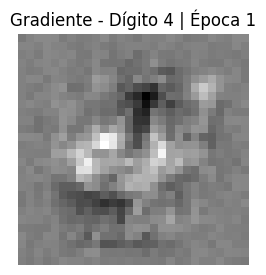

Epoch[2/100], época 0.1336, acurácia: 0.9780
weights: torch.Size([10, 784])
bias: torch.Size([10])


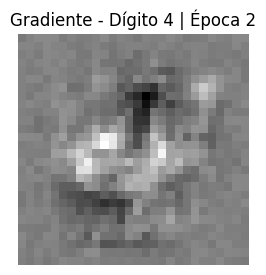

Epoch[3/100], época 0.1333, acurácia: 0.9780
weights: torch.Size([10, 784])
bias: torch.Size([10])


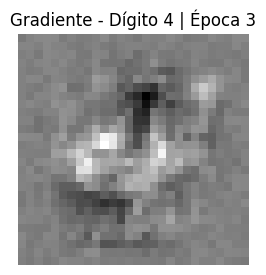

Epoch[4/100], época 0.1330, acurácia: 0.9780
weights: torch.Size([10, 784])
bias: torch.Size([10])


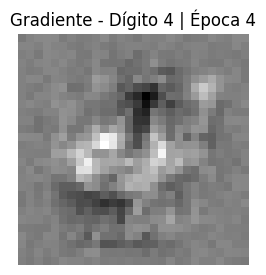

Epoch[5/100], época 0.1326, acurácia: 0.9780
weights: torch.Size([10, 784])
bias: torch.Size([10])


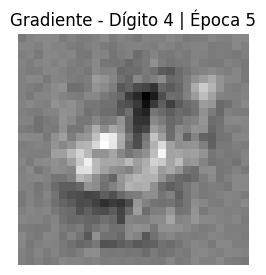

Epoch[6/100], época 0.1323, acurácia: 0.9780
weights: torch.Size([10, 784])
bias: torch.Size([10])


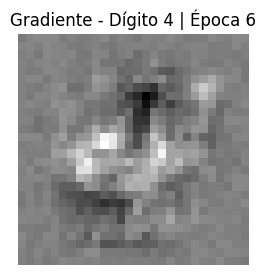

Epoch[7/100], época 0.1320, acurácia: 0.9780
weights: torch.Size([10, 784])
bias: torch.Size([10])


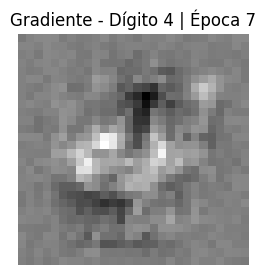

Epoch[8/100], época 0.1316, acurácia: 0.9780
weights: torch.Size([10, 784])
bias: torch.Size([10])


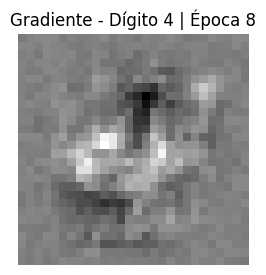

Epoch[9/100], época 0.1313, acurácia: 0.9780
weights: torch.Size([10, 784])
bias: torch.Size([10])


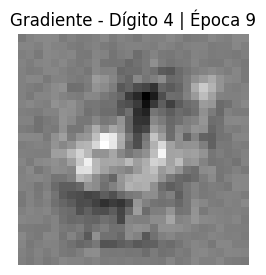

Epoch[10/100], época 0.1310, acurácia: 0.9780
weights: torch.Size([10, 784])
bias: torch.Size([10])


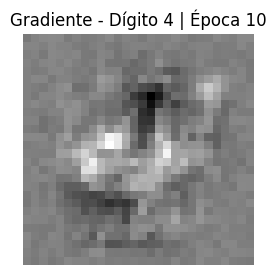

Epoch[11/100], época 0.1307, acurácia: 0.9780
weights: torch.Size([10, 784])
bias: torch.Size([10])


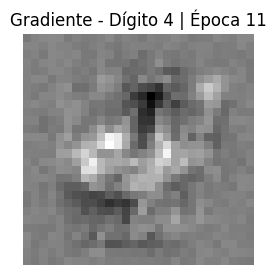

Epoch[12/100], época 0.1303, acurácia: 0.9780
weights: torch.Size([10, 784])
bias: torch.Size([10])


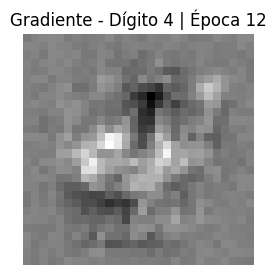

Epoch[13/100], época 0.1300, acurácia: 0.9780
weights: torch.Size([10, 784])
bias: torch.Size([10])


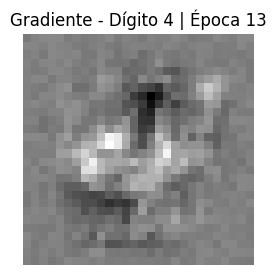

Epoch[14/100], época 0.1297, acurácia: 0.9780
weights: torch.Size([10, 784])
bias: torch.Size([10])


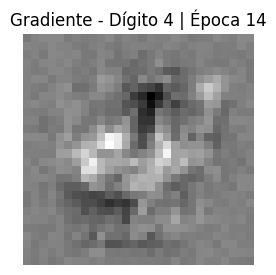

Epoch[15/100], época 0.1294, acurácia: 0.9780
weights: torch.Size([10, 784])
bias: torch.Size([10])


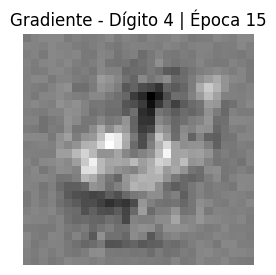

Epoch[16/100], época 0.1291, acurácia: 0.9780
weights: torch.Size([10, 784])
bias: torch.Size([10])


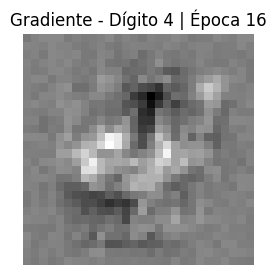

Epoch[17/100], época 0.1287, acurácia: 0.9780
weights: torch.Size([10, 784])
bias: torch.Size([10])


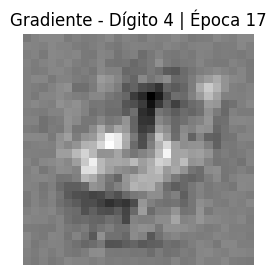

Epoch[18/100], época 0.1284, acurácia: 0.9780
weights: torch.Size([10, 784])
bias: torch.Size([10])


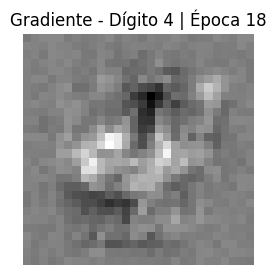

Epoch[19/100], época 0.1281, acurácia: 0.9780
weights: torch.Size([10, 784])
bias: torch.Size([10])


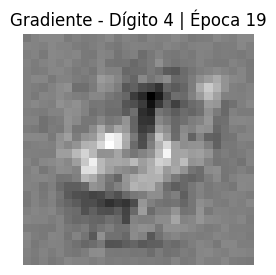

Epoch[20/100], época 0.1278, acurácia: 0.9780
weights: torch.Size([10, 784])
bias: torch.Size([10])


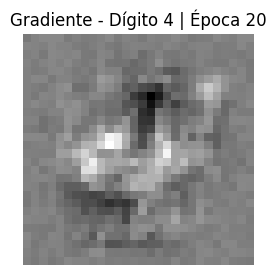

Epoch[21/100], época 0.1275, acurácia: 0.9800
weights: torch.Size([10, 784])
bias: torch.Size([10])


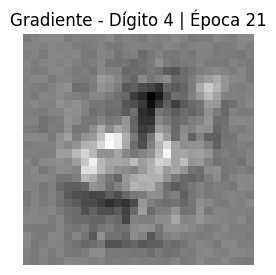

Epoch[22/100], época 0.1272, acurácia: 0.9800
weights: torch.Size([10, 784])
bias: torch.Size([10])


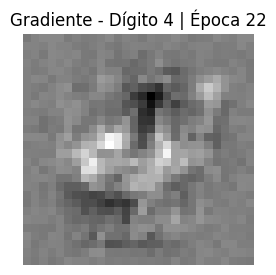

Epoch[23/100], época 0.1269, acurácia: 0.9800
weights: torch.Size([10, 784])
bias: torch.Size([10])


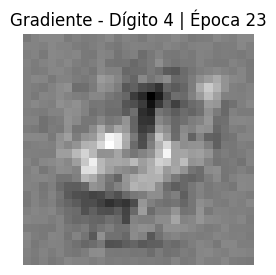

Epoch[24/100], época 0.1266, acurácia: 0.9800
weights: torch.Size([10, 784])
bias: torch.Size([10])


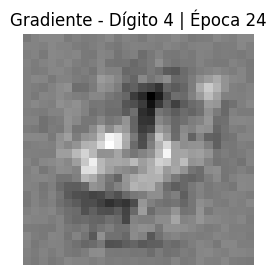

Epoch[25/100], época 0.1263, acurácia: 0.9810
weights: torch.Size([10, 784])
bias: torch.Size([10])


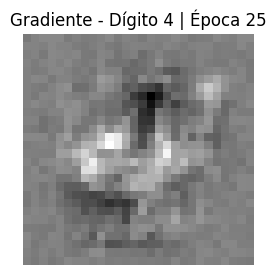

Epoch[26/100], época 0.1260, acurácia: 0.9810
weights: torch.Size([10, 784])
bias: torch.Size([10])


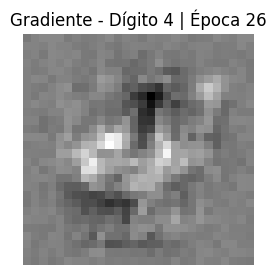

Epoch[27/100], época 0.1257, acurácia: 0.9810
weights: torch.Size([10, 784])
bias: torch.Size([10])


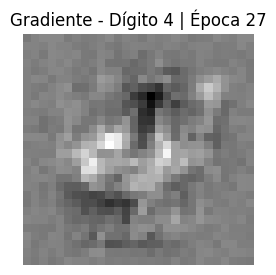

Epoch[28/100], época 0.1253, acurácia: 0.9810
weights: torch.Size([10, 784])
bias: torch.Size([10])


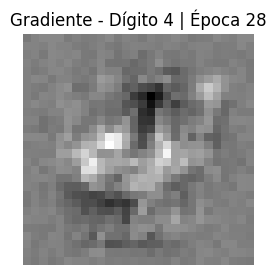

Epoch[29/100], época 0.1250, acurácia: 0.9810
weights: torch.Size([10, 784])
bias: torch.Size([10])


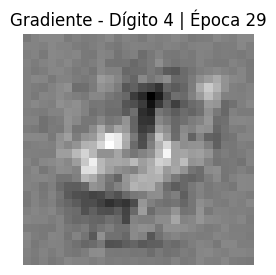

Epoch[30/100], época 0.1248, acurácia: 0.9810
weights: torch.Size([10, 784])
bias: torch.Size([10])


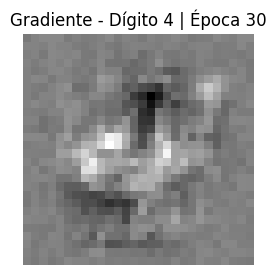

Epoch[31/100], época 0.1245, acurácia: 0.9820
weights: torch.Size([10, 784])
bias: torch.Size([10])


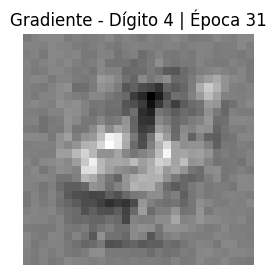

Epoch[32/100], época 0.1242, acurácia: 0.9820
weights: torch.Size([10, 784])
bias: torch.Size([10])


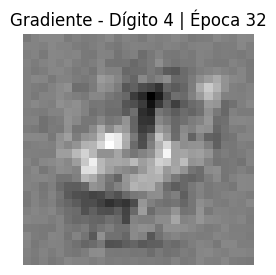

Epoch[33/100], época 0.1239, acurácia: 0.9820
weights: torch.Size([10, 784])
bias: torch.Size([10])


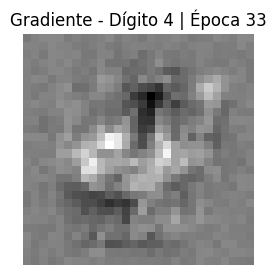

Epoch[34/100], época 0.1236, acurácia: 0.9820
weights: torch.Size([10, 784])
bias: torch.Size([10])


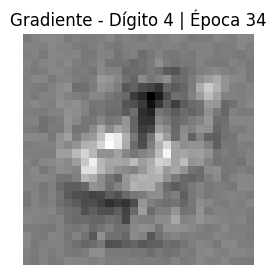

Epoch[35/100], época 0.1233, acurácia: 0.9820
weights: torch.Size([10, 784])
bias: torch.Size([10])


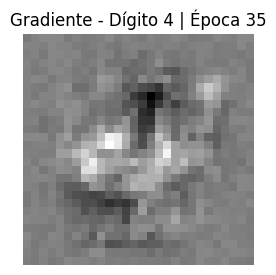

Epoch[36/100], época 0.1230, acurácia: 0.9820
weights: torch.Size([10, 784])
bias: torch.Size([10])


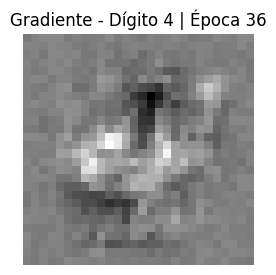

Epoch[37/100], época 0.1227, acurácia: 0.9820
weights: torch.Size([10, 784])
bias: torch.Size([10])


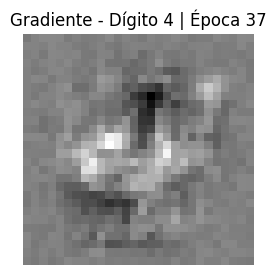

Epoch[38/100], época 0.1224, acurácia: 0.9820
weights: torch.Size([10, 784])
bias: torch.Size([10])


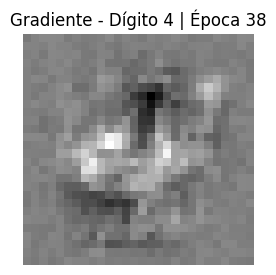

Epoch[39/100], época 0.1221, acurácia: 0.9820
weights: torch.Size([10, 784])
bias: torch.Size([10])


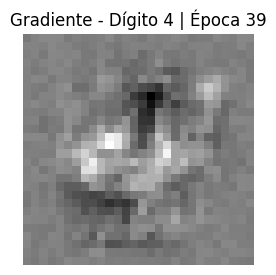

Epoch[40/100], época 0.1218, acurácia: 0.9820
weights: torch.Size([10, 784])
bias: torch.Size([10])


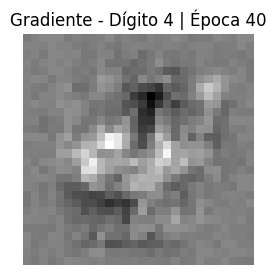

Epoch[41/100], época 0.1215, acurácia: 0.9830
weights: torch.Size([10, 784])
bias: torch.Size([10])


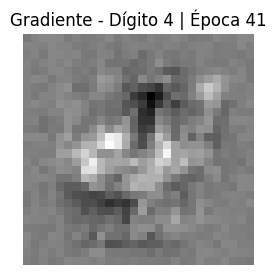

Epoch[42/100], época 0.1213, acurácia: 0.9840
weights: torch.Size([10, 784])
bias: torch.Size([10])


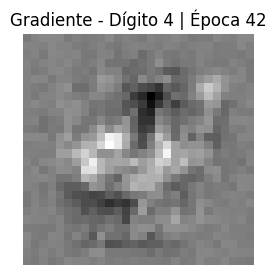

Epoch[43/100], época 0.1210, acurácia: 0.9840
weights: torch.Size([10, 784])
bias: torch.Size([10])


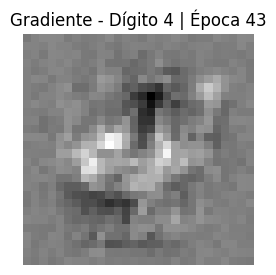

Epoch[44/100], época 0.1207, acurácia: 0.9840
weights: torch.Size([10, 784])
bias: torch.Size([10])


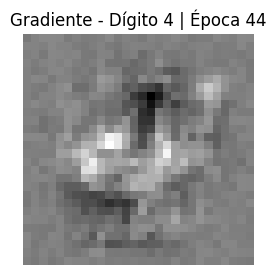

Epoch[45/100], época 0.1204, acurácia: 0.9840
weights: torch.Size([10, 784])
bias: torch.Size([10])


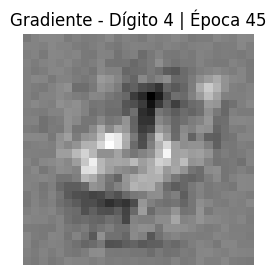

Epoch[46/100], época 0.1201, acurácia: 0.9840
weights: torch.Size([10, 784])
bias: torch.Size([10])


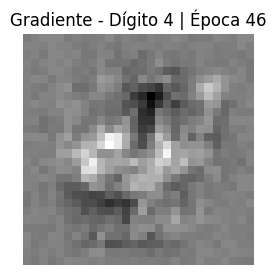

Epoch[47/100], época 0.1199, acurácia: 0.9840
weights: torch.Size([10, 784])
bias: torch.Size([10])


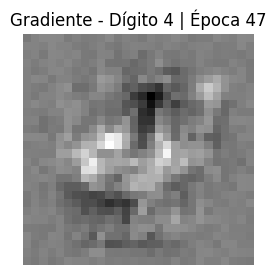

Epoch[48/100], época 0.1196, acurácia: 0.9840
weights: torch.Size([10, 784])
bias: torch.Size([10])


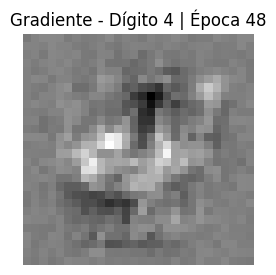

Epoch[49/100], época 0.1193, acurácia: 0.9840
weights: torch.Size([10, 784])
bias: torch.Size([10])


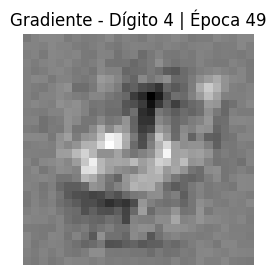

Epoch[50/100], época 0.1190, acurácia: 0.9850
weights: torch.Size([10, 784])
bias: torch.Size([10])


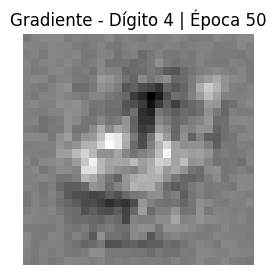

Epoch[51/100], época 0.1188, acurácia: 0.9850
weights: torch.Size([10, 784])
bias: torch.Size([10])


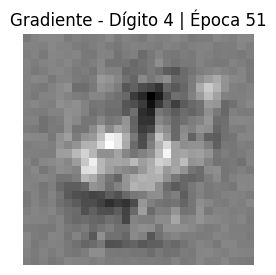

Epoch[52/100], época 0.1185, acurácia: 0.9850
weights: torch.Size([10, 784])
bias: torch.Size([10])


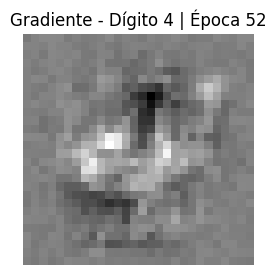

Epoch[53/100], época 0.1182, acurácia: 0.9860
weights: torch.Size([10, 784])
bias: torch.Size([10])


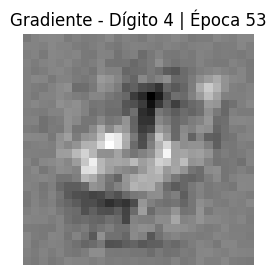

Epoch[54/100], época 0.1179, acurácia: 0.9860
weights: torch.Size([10, 784])
bias: torch.Size([10])


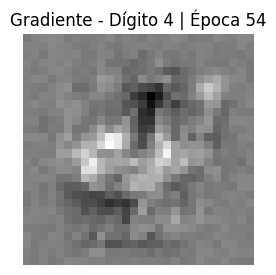

Epoch[55/100], época 0.1177, acurácia: 0.9860
weights: torch.Size([10, 784])
bias: torch.Size([10])


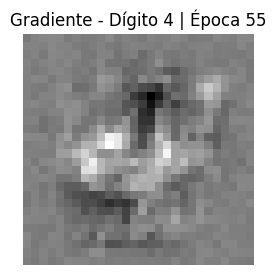

Epoch[56/100], época 0.1174, acurácia: 0.9860
weights: torch.Size([10, 784])
bias: torch.Size([10])


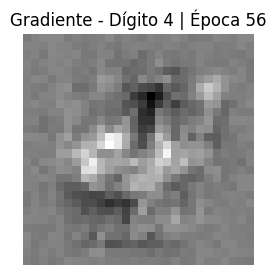

Epoch[57/100], época 0.1171, acurácia: 0.9860
weights: torch.Size([10, 784])
bias: torch.Size([10])


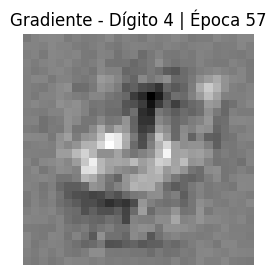

Epoch[58/100], época 0.1169, acurácia: 0.9860
weights: torch.Size([10, 784])
bias: torch.Size([10])


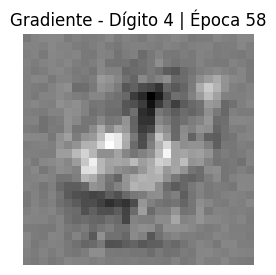

Epoch[59/100], época 0.1166, acurácia: 0.9860
weights: torch.Size([10, 784])
bias: torch.Size([10])


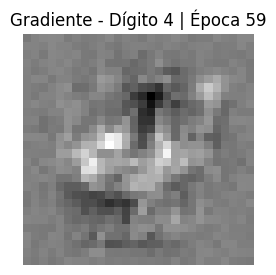

Epoch[60/100], época 0.1163, acurácia: 0.9860
weights: torch.Size([10, 784])
bias: torch.Size([10])


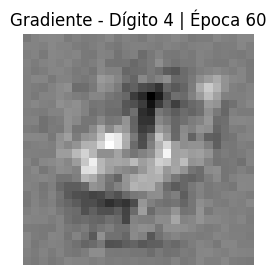

Epoch[61/100], época 0.1161, acurácia: 0.9860
weights: torch.Size([10, 784])
bias: torch.Size([10])


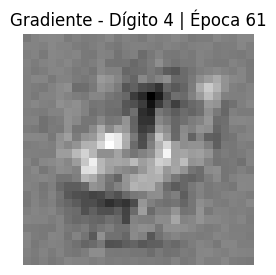

Epoch[62/100], época 0.1158, acurácia: 0.9870
weights: torch.Size([10, 784])
bias: torch.Size([10])


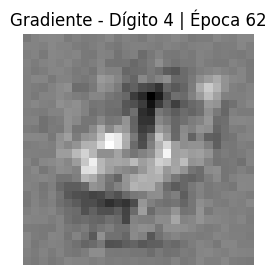

Epoch[63/100], época 0.1156, acurácia: 0.9870
weights: torch.Size([10, 784])
bias: torch.Size([10])


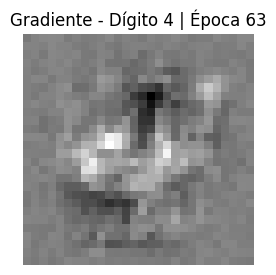

Epoch[64/100], época 0.1153, acurácia: 0.9870
weights: torch.Size([10, 784])
bias: torch.Size([10])


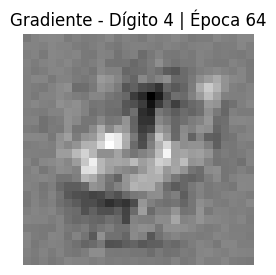

Epoch[65/100], época 0.1150, acurácia: 0.9870
weights: torch.Size([10, 784])
bias: torch.Size([10])


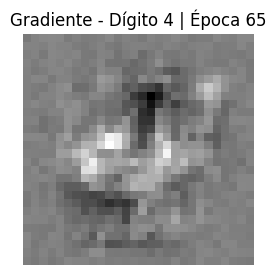

Epoch[66/100], época 0.1148, acurácia: 0.9870
weights: torch.Size([10, 784])
bias: torch.Size([10])


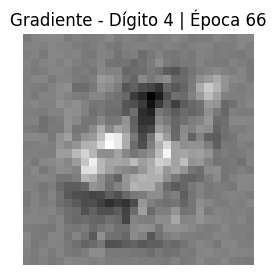

Epoch[67/100], época 0.1145, acurácia: 0.9870
weights: torch.Size([10, 784])
bias: torch.Size([10])


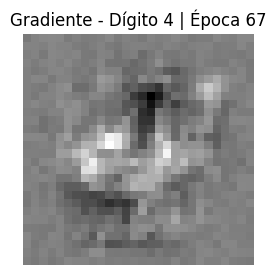

Epoch[68/100], época 0.1143, acurácia: 0.9870
weights: torch.Size([10, 784])
bias: torch.Size([10])


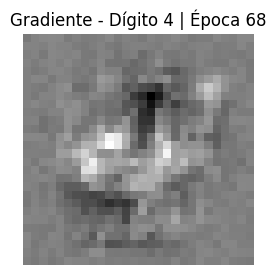

Epoch[69/100], época 0.1140, acurácia: 0.9870
weights: torch.Size([10, 784])
bias: torch.Size([10])


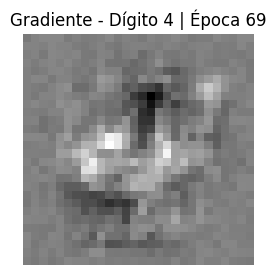

Epoch[70/100], época 0.1138, acurácia: 0.9870
weights: torch.Size([10, 784])
bias: torch.Size([10])


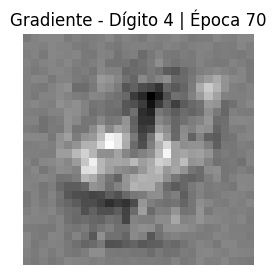

Epoch[71/100], época 0.1135, acurácia: 0.9870
weights: torch.Size([10, 784])
bias: torch.Size([10])


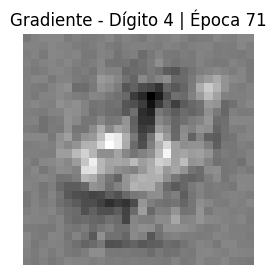

Epoch[72/100], época 0.1133, acurácia: 0.9870
weights: torch.Size([10, 784])
bias: torch.Size([10])


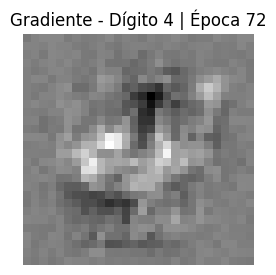

Epoch[73/100], época 0.1130, acurácia: 0.9870
weights: torch.Size([10, 784])
bias: torch.Size([10])


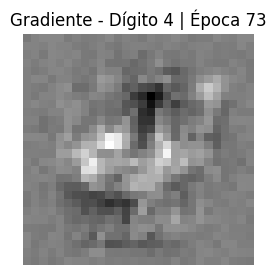

Epoch[74/100], época 0.1128, acurácia: 0.9870
weights: torch.Size([10, 784])
bias: torch.Size([10])


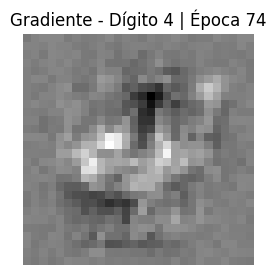

Epoch[75/100], época 0.1125, acurácia: 0.9870
weights: torch.Size([10, 784])
bias: torch.Size([10])


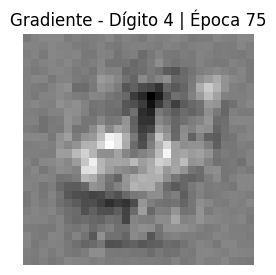

Epoch[76/100], época 0.1123, acurácia: 0.9870
weights: torch.Size([10, 784])
bias: torch.Size([10])


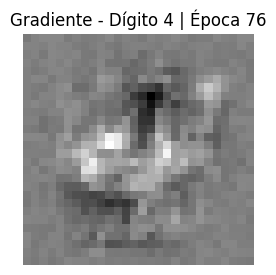

Epoch[77/100], época 0.1120, acurácia: 0.9870
weights: torch.Size([10, 784])
bias: torch.Size([10])


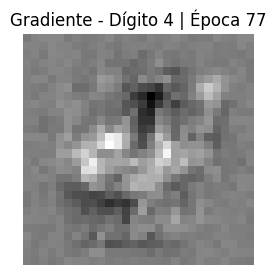

Epoch[78/100], época 0.1118, acurácia: 0.9870
weights: torch.Size([10, 784])
bias: torch.Size([10])


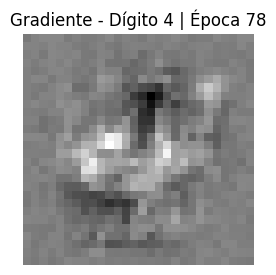

Epoch[79/100], época 0.1115, acurácia: 0.9880
weights: torch.Size([10, 784])
bias: torch.Size([10])


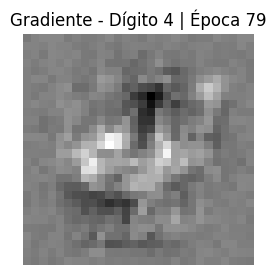

Epoch[80/100], época 0.1113, acurácia: 0.9880
weights: torch.Size([10, 784])
bias: torch.Size([10])


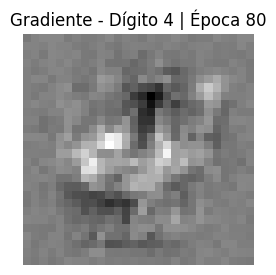

Epoch[81/100], época 0.1110, acurácia: 0.9880
weights: torch.Size([10, 784])
bias: torch.Size([10])


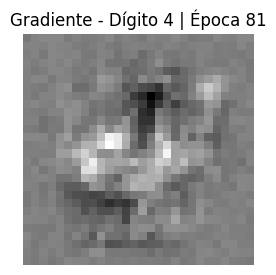

Epoch[82/100], época 0.1108, acurácia: 0.9880
weights: torch.Size([10, 784])
bias: torch.Size([10])


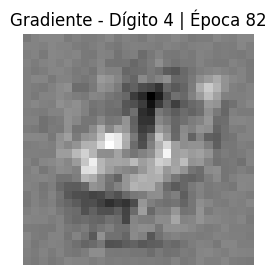

Epoch[83/100], época 0.1106, acurácia: 0.9880
weights: torch.Size([10, 784])
bias: torch.Size([10])


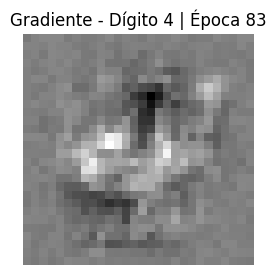

Epoch[84/100], época 0.1103, acurácia: 0.9880
weights: torch.Size([10, 784])
bias: torch.Size([10])


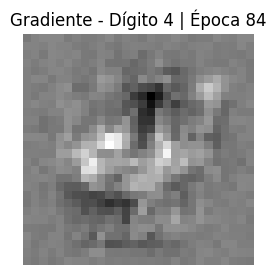

Epoch[85/100], época 0.1101, acurácia: 0.9880
weights: torch.Size([10, 784])
bias: torch.Size([10])


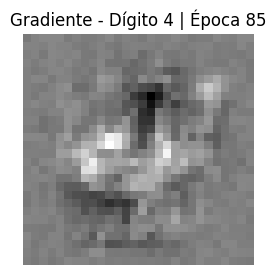

Epoch[86/100], época 0.1098, acurácia: 0.9890
weights: torch.Size([10, 784])
bias: torch.Size([10])


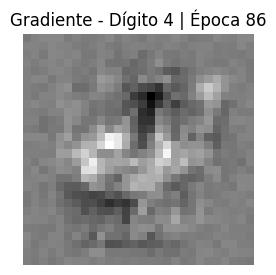

Epoch[87/100], época 0.1096, acurácia: 0.9890
weights: torch.Size([10, 784])
bias: torch.Size([10])


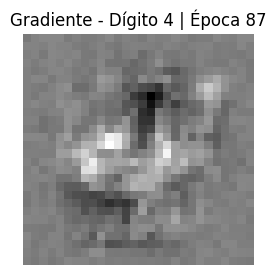

Epoch[88/100], época 0.1094, acurácia: 0.9890
weights: torch.Size([10, 784])
bias: torch.Size([10])


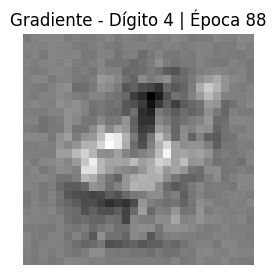

Epoch[89/100], época 0.1091, acurácia: 0.9890
weights: torch.Size([10, 784])
bias: torch.Size([10])


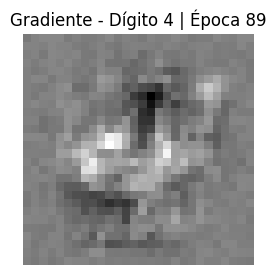

Epoch[90/100], época 0.1089, acurácia: 0.9890
weights: torch.Size([10, 784])
bias: torch.Size([10])


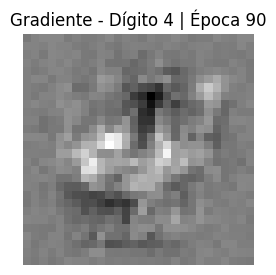

Epoch[91/100], época 0.1087, acurácia: 0.9890
weights: torch.Size([10, 784])
bias: torch.Size([10])


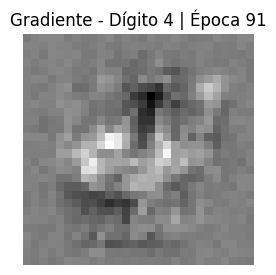

Epoch[92/100], época 0.1084, acurácia: 0.9890
weights: torch.Size([10, 784])
bias: torch.Size([10])


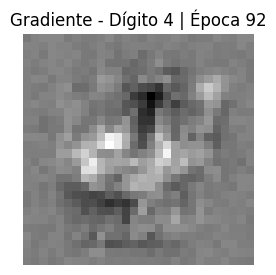

Epoch[93/100], época 0.1082, acurácia: 0.9890
weights: torch.Size([10, 784])
bias: torch.Size([10])


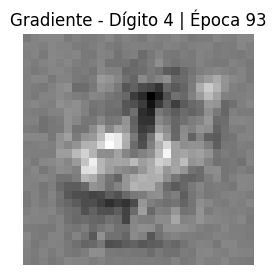

Epoch[94/100], época 0.1080, acurácia: 0.9890
weights: torch.Size([10, 784])
bias: torch.Size([10])


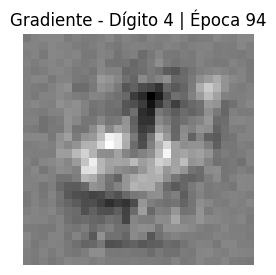

Epoch[95/100], época 0.1077, acurácia: 0.9890
weights: torch.Size([10, 784])
bias: torch.Size([10])


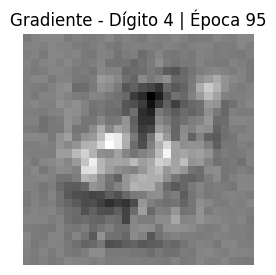

Epoch[96/100], época 0.1075, acurácia: 0.9890
weights: torch.Size([10, 784])
bias: torch.Size([10])


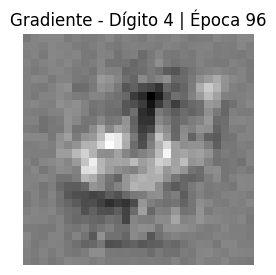

Epoch[97/100], época 0.1073, acurácia: 0.9890
weights: torch.Size([10, 784])
bias: torch.Size([10])


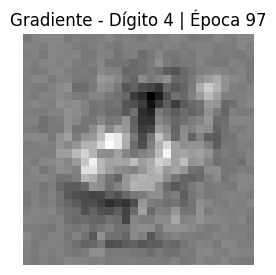

Epoch[98/100], época 0.1071, acurácia: 0.9890
weights: torch.Size([10, 784])
bias: torch.Size([10])


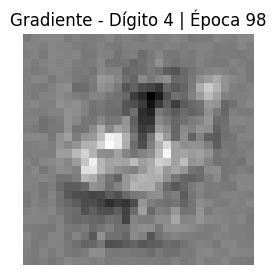

Epoch[99/100], época 0.1068, acurácia: 0.9890
weights: torch.Size([10, 784])
bias: torch.Size([10])


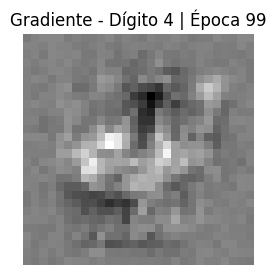

Epoch[100/100], época 0.1066, acurácia: 0.9890
weights: torch.Size([10, 784])
bias: torch.Size([10])


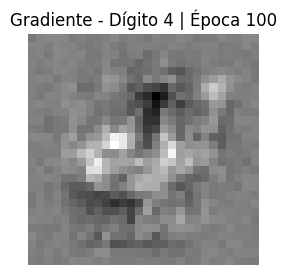

In [ ]:
losses = []
zs = []

for i in range(epochs):
    # Transforma a entrada para uma dimensão
    inputs = Variable(x_train.view(-1, 28 * 28))
    # Predict da rede
    outputs = model(inputs)

    # z0 a z9
    zs.append(outputs[1].detach().numpy())

    # calcula a perda
    loss = criterion(outputs, Variable(y_train))

    # zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    _, predicts = torch.max(outputs, 1)

    y_pred = predicts.data
    accuracy = (y_pred.numpy() == y_train.numpy()).mean()

    print('Epoch[{}/{}], época {:.4f}, acurácia: {:.4f}' .format(i+1, epochs, loss.data, accuracy))

    weights = model.state_dict()['weight']
    print('weights:', weights.shape)

    bias = model.state_dict()['bias']
    print('bias:', bias.shape)

    plt.figure(figsize=(3, 3))
    plt.imshow(weights[4, :].numpy().reshape(28, 28), cmap='gray')
    plt.title(f'Gradiente - Dígito 4 | Época {i+1}')
    plt.axis('off')
    plt.show()

<details>
<summary>Mostrar Resultado</summary>

```python
losses = []
import numpy

import numpy
zs = []

for i in range(epochs):
    # Transforma a entrada para uma dimensão
    inputs = Variable(x_train.view(-1, 28 * 28))
    # Predict da rede
    outputs = model(inputs)
    
    # z0 a z9
    zs.append(outputs[1].detach().numpy())

    # calcula a perda
    loss = criterion(outputs, Variable(y_train))

    # zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    
    _, predicts = torch.max(outputs, 1)
    
    y_pred = predicts.data
    accuracy = (y_pred.numpy() == y_train.numpy()).mean()
    
    print('Epoch[{}/{}], loss: {:.6f}, acc: {:.6f}'
              .format(i+1, epochs, loss.data, accuracy))
    
    weights = model.state_dict()['weight']
    print('weights:', weights.shape)

    bias = model.state_dict()['bias']
    print('bias:   ', bias.shape)

    # Visualizando pesos da classe 3
    plt.imshow(weights[4, :].numpy().reshape((28,28)),cmap = 'gray')
    plt.show()
```

</details>

## Perguntas

1. Qual é o shape da matriz de entrada na rede?
2. Qual é o shape da saída da rede?
3. Qual é o número total de parâmetros da rede, incluindo o bias?

1. Qual é o shape da matriz de entrada na rede?

        R.: [1000, 784]

2. Qual é o shape da saída da rede?

        R.: [1, 10]

3. Qual é o número total de parâmetros da rede, incluindo o bias?

        R.: 7840 parametros na rede + 10 bias = 7850 params

# Aprendizados


O número de parâmetros de uma rede neural é proporcional à quantidade de entradas e ao número de classes do problema. Isso influencia diretamente a capacidade de aprendizado do modelo, além de impactar o custo e a demanda computacional durante o treinamento e a execução.

Além disso, o monitoramento da perda (loss) e da acurácia é fundamental para acompanhar o desempenho do modelo ao longo do treinamento, permitindo identificar problemas como overfitting, quando o modelo memoriza os dados de treino, e underfitting, quando ele não consegue aprender adequadamente os padrões dos dados.